**First things first** - please go to 'File' and select 'Save a copy in Drive' so that you have your own version of this activity set up and ready to use.
Remember to update the portfolio index link to your own work once completed!

# Activity 2.2.6 Sentiment analysis and text classification

In this activity, you will build a sentiment analysis model using Python and a data set of customer reviews. You will preprocess the data and fine-tune, evaluate, and test the model.


## Objective
In this activity, you will download a data set from Hugging Face and conduct text classification on it. Your objective is to analyse how different parameter choices affect the performance of a sentiment classifier.

You will complete this in your Notebook, where you will:

- create and train sentiment classifier RNN models
- evaluate model performance.



## Assessment criteria

By completing this activity, you will be able to provide evidence that you can:
*   apply various text preprocessing techniques and representation methods to preprocess and analyse textual data.
*   comprehend and implement different types of recurrent neural networks (RNNs) and understand their applications in NLP.
*   build and fine-tune advanced NLP models for specific natural language processing tasks.


## Activity guidance

1. Install the necessary packages that will be useful in this activity
2. Load the dataset sst5 from hugging face (https://huggingface.co/datasets/SetFit/sst5)

3. Create dataframes of the train and train split
4. Split the train dataframe into train and validation in the ratio of 8:2
5. Preprocess the dataset, set the maximum size to 200, vocabulary size to 30000
6. During tokenisation, mark out of vocabulary words as "[OOV]"
7. Pad your sequences with special tokens
8. Train a sentiment classifier on the dataset and compare different models for text classification
9.Train for 5 epochs
- Train with a vanilla RNN
- Train with an LSTM
- Is there any difference between a GRU and an LSTM?
- Train with a bidirectional LSTM
10. Comment on the performance of all the models


In [ ]:
# In this activity, you will be required to download a dataset from huggingface and perfom the text classification on the the dataset
# You will be required to study the impact of different different parameter choices on the classification perfomance of sentiment classifier


# 1. Install the necessary packages that will be useful in this  activity
# 2. Load the dataset sst5 from hugginface (https://huggingface.co/datasets/SetFit/sst5)
# 3.Create dataframes of the train and train split
# 4 Split the train dataframe into train and validation in the ratio of 8:2
# 5 Preprocess the dataset,  set the maximum size to 200, vocabulary size to 30000
# 6. During tokenization, mark out of vocabulary words as "<OOV>"
# 7 Pad your sequences with special tokens
# 8. Train a sentiment classifier on the dataset and compare different models for text classification
# Train for 5 epochs
#    - Train with a vanilla RNN
#    - Train with an LSTM
#    - Is there any difference between a GRU and an LSTM?
#    - Train with a bidirectional LSTM
# Comment on the perfomance of all the models

In [1]:
%pip install tensorflow datasets pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.5/223.5 MB 22.7 MB/s  0:00:09m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 24.9 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 25.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 16.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 22.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 26.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [tensorflow]7 [tensorflow]
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Bidirectional,
    Dense,
)
from dotenv import load_dotenv
import os

In [7]:
load_dotenv()
hf_token = os.getenv("HF_TOKEN")

In [9]:
# Load dataset
dataset = load_dataset("SetFit/sst5")

README.md:   0%|          | 0.00/421 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl: 0.00B [00:00, ?B/s]

dev.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/8544 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1101 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2210 [00:00<?, ? examples/s]

In [ ]:
# Split dataset
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

display(train_df.head())
test_df.head()

,text,label,label_text
0,"a stirring , funny and finally transporting re...",4,very positive
1,apparently reassembled from the cutting-room f...,1,negative
2,they presume their audience wo n't sit still f...,1,negative
3,the entire movie is filled with deja vu moments .,2,neutral
4,this is a visually stunning rumination on love...,3,positive


,text,label,label_text
0,"no movement , no yuks , not much of anything .",1,negative
1,"a gob of drivel so sickly sweet , even the eag...",0,very negative
2,` how many more voyages can this limping but d...,2,neutral
3,so relentlessly wholesome it made me want to s...,2,neutral
4,"gangs of new york is an unapologetic mess , wh...",0,very negative


In [ ]:
# See all unique label values
print(train_df["label"].unique())

# See how many there are
print(train_df["label"].nunique())

# See how many examples per class (useful to spot imbalance too)
print(train_df["label"].value_counts().sort_index())

[4 1 2 3 0]
5
label
0    1092
1    2218
2    1624
3    2322
4    1288
Name: count, dtype: int64


In [ ]:
# split validation set
X_train, X_val, y_train, y_val = train_test_split(
    train_df["text"], train_df["label"], test_size=0.2, random_state=42
)

In [14]:
# Tokenise with OOV token
VOCAB_SIZE = 30000
OOV_TOKEN = "[OOV]"

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
# fit on training data only
tokenizer.fit_on_texts(X_train)

In [15]:
# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)

len(X_train_seq)

6835

In [ ]:
# Pad sequences
MAX_LEN = 200

X_train_pad = pad_sequences(
    X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post"
)
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding="post", truncating="post")

In [17]:
# Prepare the label. Keras expects numpy arrays
y_train_arr = np.array(y_train)
y_val_arr = np.array(y_val)

In [ ]:
# Sanity check
print(f"Training samples:   {X_train_pad.shape}")  # should be (n, 200)
print(f"Validation samples: {X_val_pad.shape}")  # should be (n, 200)
print(f"Vocabulary size:    {len(tokenizer.word_index)}")
print(f"Number of classes:  {len(set(y_train_arr))}")  # should be 5

Training samples:   (6835, 200)
Validation samples: (1709, 200)
Vocabulary size:    13813
Number of classes:  5


In [ ]:
# Build the models
EMBEDDING_DIM = 64  # size of each word's vector. 64 is the standard to start off with. can hyperparam tune
NUM_CLASSES = 5

# Simple RNN
vanilla_rnn = Sequential(
    [
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
        SimpleRNN(64),
        Dense(NUM_CLASSES, activation="softmax"),
    ]
)

vanilla_rnn.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

vanilla_rnn.summary()

/opt/anaconda3/envs/cam-ds-course/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# LSTM model
lstm_model = Sequential(
    [
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
        LSTM(64),
        Dense(NUM_CLASSES, activation="softmax"),
    ]
)

lstm_model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [ ]:
# GRU model
gru_model = Sequential(
    [
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
        GRU(64),
        Dense(NUM_CLASSES, activation="softmax"),
    ]
)

gru_model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [ ]:
# Bidirectional LSTM
bi_lstm = Sequential(
    [
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(64)),
        Dense(NUM_CLASSES, activation="softmax"),
    ]
)

bi_lstm.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [28]:
# ---------------------------------------------------------------------------- #
#                               Train the models                               #
# ---------------------------------------------------------------------------- #
EPOCHS = 5
BATCH_SIZE = 64

history_rnn = vanilla_rnn.fit(
    X_train_pad,
    y_train_arr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val_arr),
)
history_lstm = lstm_model.fit(
    X_train_pad,
    y_train_arr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val_arr),
)
history_gru = gru_model.fit(
    X_train_pad,
    y_train_arr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val_arr),
)
history_bi = bi_lstm.fit(
    X_train_pad,
    y_train_arr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val_arr),
)

Epoch 1/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.2695 - loss: 1.5763 - val_accuracy: 0.2779 - val_loss: 1.5669
Epoch 2/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.2499 - loss: 1.5794 - val_accuracy: 0.2621 - val_loss: 1.5721
Epoch 3/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.2623 - loss: 1.5779 - val_accuracy: 0.2838 - val_loss: 1.5630
Epoch 4/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.2682 - loss: 1.5776 - val_accuracy: 0.2610 - val_loss: 1.5650
Epoch 5/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.2669 - loss: 1.5752 - val_accuracy: 0.2697 - val_loss: 1.5651
Epoch 1/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 9s 84ms/step - accuracy: 0.2658 - loss: 1.5707 - val_accuracy: 0.2779 - val_loss: 1.5602
Epoch 2/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.2664 - loss: 1.5706 - val_accuracy: 0.2779 - val_loss: 1.5616
Epoch 3/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.2682 - loss: 1.5706 - val_accuracy: 0.

In [29]:
# ---------------------------------------------------------------------------- #
#                             Generate predictions                             #
# ---------------------------------------------------------------------------- #

# Get predicted class for each model (argmax picks the highest probability class)
y_pred_rnn = np.argmax(vanilla_rnn.predict(X_val_pad), axis=1)
y_pred_lstm = np.argmax(lstm_model.predict(X_val_pad), axis=1)
y_pred_gru = np.argmax(gru_model.predict(X_val_pad), axis=1)
y_pred_bi = np.argmax(bi_lstm.predict(X_val_pad), axis=1)

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


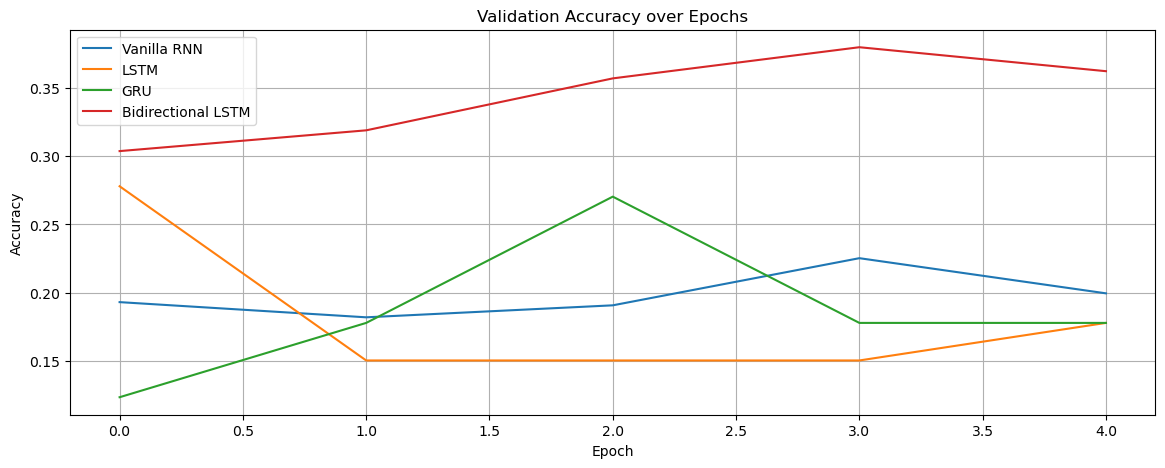

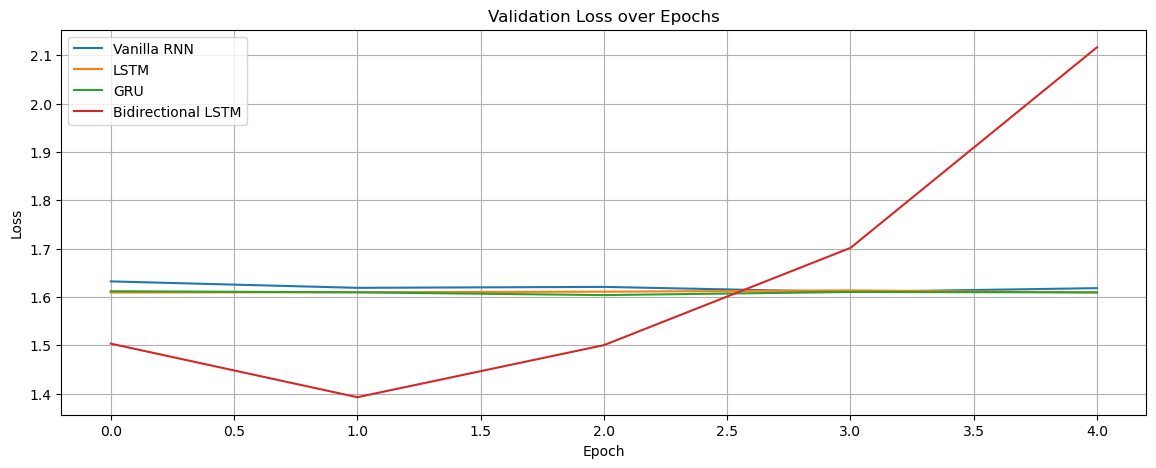

In [ ]:
import matplotlib.pyplot as plt


def plot_history(histories, metric="accuracy"):
    plt.figure(figsize=(14, 5))

    for name, history in histories.items():
        plt.plot(history.history[f"val_{metric}"], label=name)

    plt.title(f"Validation {metric.capitalize()} over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel(metric.capitalize())
    plt.legend()
    plt.grid(True)
    plt.show()


histories = {
    "Vanilla RNN": history_rnn,
    "LSTM": history_lstm,
    "GRU": history_gru,
    "Bidirectional LSTM": history_bi,
}

plot_history(histories, metric="accuracy")
plot_history(histories, metric="loss")

In [30]:
# Classification reports
label_names = ["very negative", "negative", "neutral", "positive", "very positive"]

models = {
    "Vanilla RNN": y_pred_rnn,
    "LSTM": y_pred_lstm,
    "GRU": y_pred_gru,
    "Bidirectional LSTM": y_pred_bi,
}

for name, preds in models.items():
    print(f"\n{'=' * 50}")
    print(f"  {name}")
    print(f"{'=' * 50}")
    print(f"Accuracy: {accuracy_score(y_val_arr, preds):.4f}")
    print(classification_report(y_val_arr, preds, target_names=label_names))


  Vanilla RNN
Accuracy: 0.2697
               precision    recall  f1-score   support

very negative       0.00      0.00      0.00       211
     negative       0.27      0.56      0.36       462
      neutral       0.00      0.00      0.00       304
     positive       0.27      0.42      0.33       475
very positive       0.00      0.00      0.00       257

     accuracy                           0.27      1709
    macro avg       0.11      0.20      0.14      1709
 weighted avg       0.15      0.27      0.19      1709


  LSTM
Accuracy: 0.2779
               precision    recall  f1-score   support

very negative       0.00      0.00      0.00       211
     negative       0.00      0.00      0.00       462
      neutral       0.00      0.00      0.00       304
     positive       0.28      1.00      0.43       475
very positive       0.00      0.00      0.00       257

     accuracy                           0.28      1709
    macro avg       0.06      0.20      0.09      1709
 we

/opt/anaconda3/envs/cam-ds-course/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/cam-ds-course/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/cam-ds-course/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [41]:
# Stacked Bidirectional LSTM Model

bi_lstm_stacked = Sequential(
    [
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dense(NUM_CLASSES, activation="softmax"),
    ]
)

bi_lstm_stacked.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)


/opt/anaconda3/envs/cam-ds-course/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [42]:
history_bi_stacked = bi_lstm_stacked.fit(
    X_train_pad,
    y_train_arr,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val_arr),
)

Epoch 1/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 37s 297ms/step - accuracy: 0.2947 - loss: 1.5507 - val_accuracy: 0.3511 - val_loss: 1.4850
Epoch 2/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 43s 400ms/step - accuracy: 0.4527 - loss: 1.2552 - val_accuracy: 0.3996 - val_loss: 1.3623
Epoch 3/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 44s 409ms/step - accuracy: 0.6416 - loss: 0.8719 - val_accuracy: 0.3839 - val_loss: 1.6005
Epoch 4/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 44s 412ms/step - accuracy: 0.8053 - loss: 0.5305 - val_accuracy: 0.3716 - val_loss: 2.0374
Epoch 5/5
107/107 ━━━━━━━━━━━━━━━━━━━━ 44s 409ms/step - accuracy: 0.8851 - loss: 0.3278 - val_accuracy: 0.3727 - val_loss: 2.3400


In [43]:
y_pred_bi_stacked = np.argmax(bi_lstm_stacked.predict(X_val_pad), axis=1)

54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step


In [44]:
print(f"\n{'=' * 50}")
print("Bidirectional LSTM stacked")
print(f"{'=' * 50}")
print(f"Accuracy: {accuracy_score(y_val_arr, y_pred_bi_stacked):.4f}")
print(classification_report(y_val_arr, y_pred_bi_stacked, target_names=label_names))


Bidirectional LSTM stacked
Accuracy: 0.3727
               precision    recall  f1-score   support

very negative       0.34      0.25      0.28       211
     negative       0.42      0.49      0.45       462
      neutral       0.23      0.19      0.21       304
     positive       0.39      0.40      0.40       475
very positive       0.39      0.42      0.41       257

     accuracy                           0.37      1709
    macro avg       0.35      0.35      0.35      1709
 weighted avg       0.36      0.37      0.37      1709



In [46]:
# More epochs Bidirectional LSTM stacked
bi_lstm_stacked_2 = Sequential(
    [
        Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dense(NUM_CLASSES, activation="softmax"),
    ]
)

bi_lstm_stacked_2.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

history_bi_stacked_2 = bi_lstm_stacked_2.fit(
    X_train_pad,
    y_train_arr,
    epochs=10,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val_arr),
)

Epoch 1/10


/opt/anaconda3/envs/cam-ds-course/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


107/107 ━━━━━━━━━━━━━━━━━━━━ 37s 308ms/step - accuracy: 0.2789 - loss: 1.5540 - val_accuracy: 0.3528 - val_loss: 1.4767
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 45s 425ms/step - accuracy: 0.4495 - loss: 1.2787 - val_accuracy: 0.4084 - val_loss: 1.3990
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 43s 399ms/step - accuracy: 0.6315 - loss: 0.8989 - val_accuracy: 0.4026 - val_loss: 1.5719
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 43s 406ms/step - accuracy: 0.7835 - loss: 0.5803 - val_accuracy: 0.3569 - val_loss: 1.8006
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 45s 420ms/step - accuracy: 0.8784 - loss: 0.3476 - val_accuracy: 0.3458 - val_loss: 2.2026
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 45s 418ms/step - accuracy: 0.9324 - loss: 0.2074 - val_accuracy: 0.3569 - val_loss: 2.3881
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 47s 438ms/step - accuracy: 0.9570 - loss: 0.1377 - val_accuracy: 0.3528 - val_loss: 2.6830
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 48s 452ms/step - accuracy: 0.9637 - loss: 0.1161 - val

In [47]:
y_pred_bi_stacked_2 = np.argmax(bi_lstm_stacked_2.predict(X_val_pad), axis=1)

54/54 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step


In [48]:
print(f"\n{'=' * 50}")
print("Bidirectional LSTM stacked (epoch 10)")
print(f"{'=' * 50}")
print(f"Accuracy: {accuracy_score(y_val_arr, y_pred_bi_stacked_2):.4f}")
print(classification_report(y_val_arr, y_pred_bi_stacked_2, target_names=label_names))


Bidirectional LSTM stacked (epoch 10)
Accuracy: 0.3493
               precision    recall  f1-score   support

very negative       0.26      0.34      0.29       211
     negative       0.42      0.30      0.35       462
      neutral       0.26      0.36      0.30       304
     positive       0.43      0.40      0.41       475
very positive       0.38      0.35      0.36       257

     accuracy                           0.35      1709
    macro avg       0.35      0.35      0.34      1709
 weighted avg       0.37      0.35      0.35      1709



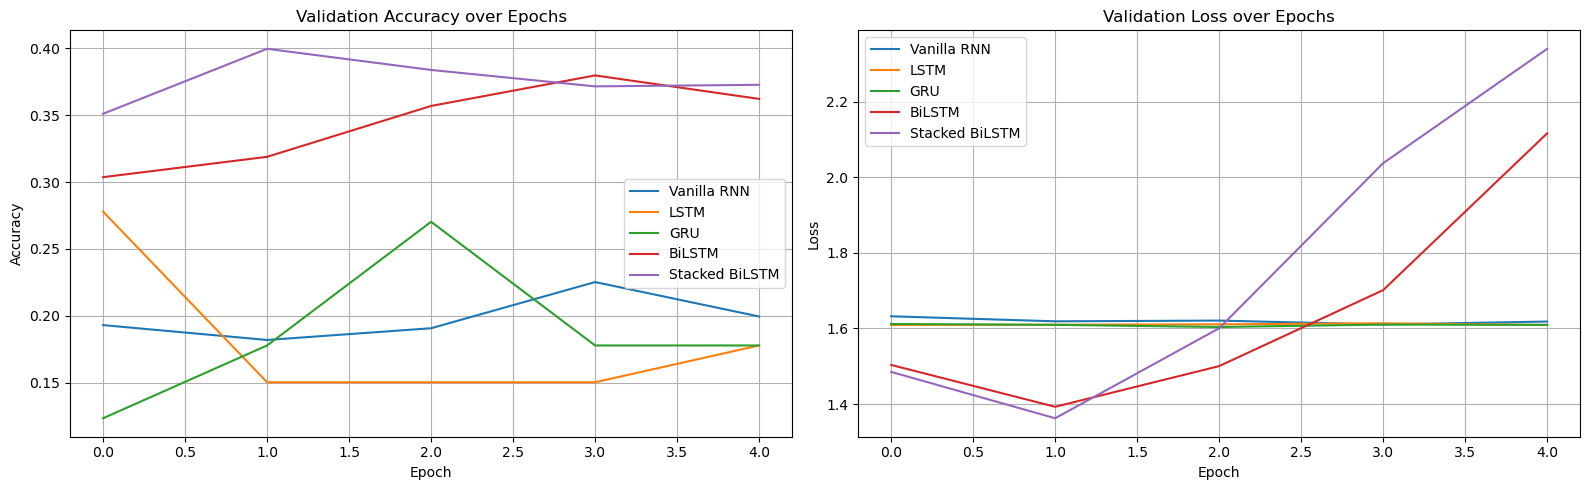

In [49]:
# Store all histories with labels
histories = {
    'Vanilla RNN':          history_rnn,
    'LSTM':                 history_lstm,
    'GRU':                  history_gru,
    'BiLSTM':               history_bi,
    'Stacked BiLSTM':       history_bi_stacked,
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for name, history in histories.items():
    axes[0].plot(history.history['val_accuracy'], label=name)
    axes[1].plot(history.history['val_loss'], label=name)

# Accuracy plot
axes[0].set_title('Validation Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].set_title('Validation Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [51]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_arr),
    y=y_train_arr
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(1.5516458569807037), 1: np.float64(0.7784738041002278), 2: np.float64(1.0356060606060606), 3: np.float64(0.7401191120736329), 4: np.float64(1.3258971871968963)}


In [52]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

fit_args = dict(
    epochs=20,  # set high — early stopping will decide when to stop
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val_arr),
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

# Rebuild and retrain all models
# --- Vanilla RNN ---
vanilla_rnn = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    SimpleRNN(64, dropout=0.2),
    Dense(NUM_CLASSES, activation='softmax')
])
vanilla_rnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_rnn = vanilla_rnn.fit(X_train_pad, y_train_arr, **fit_args)

# --- LSTM ---
lstm_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(NUM_CLASSES, activation='softmax')
])
lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_lstm = lstm_model.fit(X_train_pad, y_train_arr, **fit_args)

# --- GRU ---
gru_model = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    GRU(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(NUM_CLASSES, activation='softmax')
])
gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_gru = gru_model.fit(X_train_pad, y_train_arr, **fit_args)

# --- Bidirectional LSTM ---
bi_lstm = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(NUM_CLASSES, activation='softmax')
])
bi_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_bi = bi_lstm.fit(X_train_pad, y_train_arr, **fit_args)

# --- Stacked Bidirectional LSTM ---
stacked_bi_lstm = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2, return_sequences=True)),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(NUM_CLASSES, activation='softmax')
])
stacked_bi_lstm.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_bi_stacked = stacked_bi_lstm.fit(X_train_pad, y_train_arr, **fit_args)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.1836 - loss: 1.6188 - val_accuracy: 0.1235 - val_loss: 1.6164
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.1944 - loss: 1.6141 - val_accuracy: 0.1235 - val_loss: 1.6166
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.1737 - loss: 1.6139 - val_accuracy: 0.1504 - val_loss: 1.6233
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.2022 - loss: 1.6138 - val_accuracy: 0.1568 - val_loss: 1.6318
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.1883 - loss: 1.6267 - val_accuracy: 0.1551 - val_loss: 1.6520
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.1974 - loss: 1.6181 - val_accuracy: 0.1650 - val_loss: 1.6170
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.2123 - loss: 1.6132 - val_accuracy: 0.1428 - val_loss: 1.6645
Epoch 8/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.2040 - loss: 1.6164 - val_accu

In [53]:
y_pred_rnn       = np.argmax(vanilla_rnn.predict(X_val_pad), axis=1)
y_pred_lstm      = np.argmax(lstm_model.predict(X_val_pad), axis=1)
y_pred_gru       = np.argmax(gru_model.predict(X_val_pad), axis=1)
y_pred_bi        = np.argmax(bi_lstm.predict(X_val_pad), axis=1)
y_pred_bi_stacked = np.argmax(stacked_bi_lstm.predict(X_val_pad), axis=1)

models = {
    'Vanilla RNN':        y_pred_rnn,
    'LSTM':               y_pred_lstm,
    'GRU':                y_pred_gru,
    'BiLSTM':             y_pred_bi,
    'Stacked BiLSTM':     y_pred_bi_stacked
}

for name, preds in models.items():
    print(f"\n{'='*50}\n  {name}\n{'='*50}")
    print(f"Accuracy: {accuracy_score(y_val_arr, preds):.4f}")
    print(classification_report(y_val_arr, preds, target_names=label_names))

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 88ms/step

  Vanilla RNN
Accuracy: 0.2633
               precision    recall  f1-score   support

very negative       0.00      0.00      0.00       211
     negative       0.27      0.90      0.42       462
      neutral       0.00      0.00      0.00       304
     positive       0.29      0.04      0.08       475
very positive       0.12      0.05      0.07       257

     accuracy                           0.26      1709
    macro avg       0.14      0.20      0.11      1709
 weighted avg       0.17      0.26      0.14      1709


  LSTM
Accuracy: 0.2703
               precision    recall  f1-score   support

very negative       0.00      0.00      0.00       211
     negative       0.27      1.00      0.43       462
      neutral       0.00      0.00      0.00       304
     positive       0.00 

/opt/anaconda3/envs/cam-ds-course/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/cam-ds-course/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/cam-ds-course/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

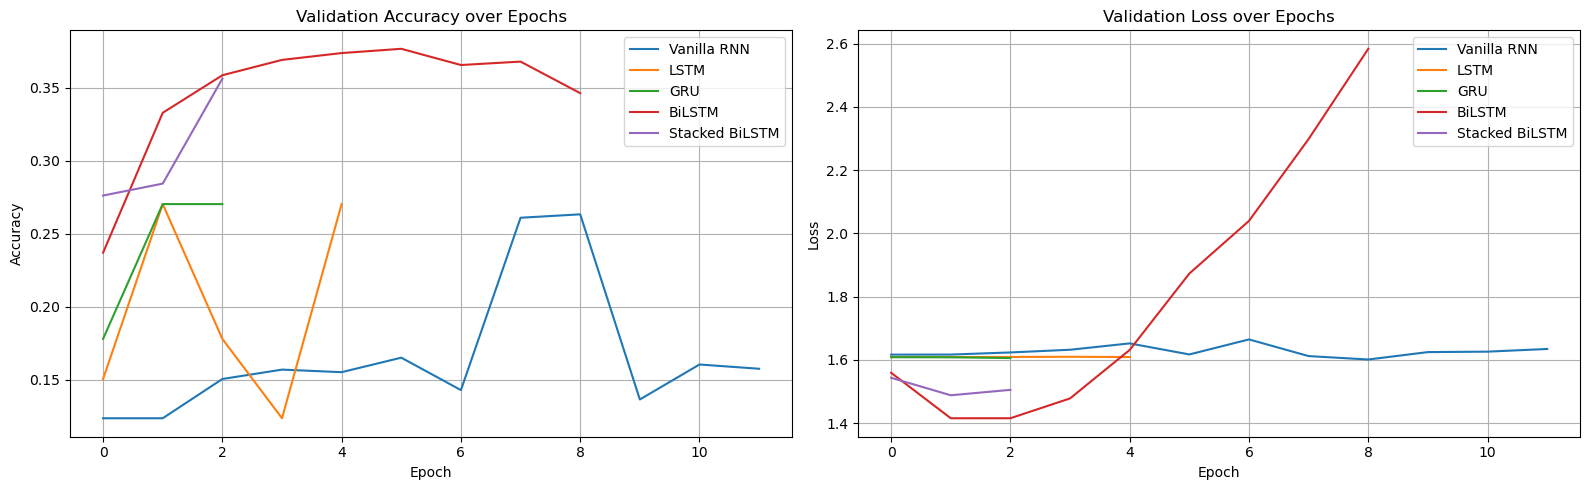

In [54]:
histories = {
    'Vanilla RNN':    history_rnn,
    'LSTM':           history_lstm,
    'GRU':            history_gru,
    'BiLSTM':         history_bi,
    'Stacked BiLSTM': history_bi_stacked
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for name, history in histories.items():
    axes[0].plot(history.history['val_accuracy'], label=name)
    axes[1].plot(history.history['val_loss'], label=name)

axes[0].set_title('Validation Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].set_title('Validation Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

The results demonstrate that architectural complexity does not guarantee better performance under constrained training conditions. The BiLSTM was the clear winner (37.7%), being the only model to successfully predict all five sentiment classes. The simpler models (Vanilla RNN, LSTM, GRU) all collapsed to majority class prediction due to insufficient training time and class imbalance. Stacking BiLSTM layers proved counterproductive, as the added parameters required more training time than the experimental setup allowed. Early stopping was essential in preventing overfitting, particularly for the BiLSTM where this was clearly visible in the loss curve. Overall, bidirectional processing was the single most impactful architectural choice in this experiment.